In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
ENV_NAME = 'cheetah' # cheetah | walker

In [3]:
BENCHMARK_SET = [0, 1, 2, 3]

NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 18
    ACTION_DIM = 6
    AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 27
    ACTION_DIM = 6
    AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [5]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_):
    return dataset_

def denormalize_dataset_coords(dataset_):
    return dataset_

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
x = dataset_trajectories_cuda[::10, ::10].reshape(1, -1, STATE_DIM)

In [8]:
class MiniMLPs(nn.Module):
    def __init__(self, N):
        super(MiniMLPs, self).__init__()
        self.N = N
        self.C = 0
        self.mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(STATE_DIM, 32),
                nn.Identity(),
                nn.Linear(32, 32),
                nn.Identity(),
                nn.Linear(32, 1),
                nn.Tanh()
            )
            for i in range(N)
        ])

    def forward(self, x, ids=None):
        rewards = []
        with torch.no_grad():

            if ids is None:
                ids = list(range(len(self.mlps)))
            
            for i in ids:
                r = self.mlps[i](x)
                rewards.append(r)
        
        rewards = torch.concat(rewards)
        
        return rewards

In [9]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, lr=1e-3, device=device):
        super(VAE, self).__init__()
        self.device = device
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Sequential(
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh(),
        )
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()  # use sigmoid if data ∈ [0,1]
        )
        
        # Optimizer
        self.optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        self.to(self.device)
        
        self.losses = []
        self.recon_losses, self.kl_divs = [], []

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        # return mu + eps * std
        return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def loss_function(self, x, x_recon, mu, logvar):
        # Reconstruction loss
        # recon_loss = (x_recon - x).pow(2).mean()
        recon_loss = (x_recon - x).abs().mean()
        # KL divergence
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + 0*kl_div, (
            recon_loss.detach().item(), 
            kl_div.detach().item()
        )

    def train_model(self, bds, batch_size=128, epochs=10, log=True):

        self.train()
        N = bds.size(0)
        bds = bds.to(self.device)
        
        

        for epoch in range(1, epochs + 1):
            # shuffle indices
            perm = torch.randperm(N, device=self.device)
            total_loss = 0
            total_recon_loss = 0
            total_kl_div = 0
            steps = 0

            for batch_idx, i in enumerate(range(0, N, batch_size)):
                idx = perm[i:i+batch_size]
                x = bds[idx]

                self.optimizer.zero_grad()
                x_recon, mu, logvar = self.forward(x)
                loss, (recon_loss, kl_div) = self.loss_function(x, x_recon, mu, logvar)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
                total_recon_loss += recon_loss
                total_kl_div += kl_div
                steps += 1
                
                
            self.losses.append(total_loss / steps)
            self.recon_losses.append(total_recon_loss / steps)
            self.kl_divs.append(total_kl_div / steps)
            
            if log == True and epoch % 10 == 0:
                clear_output(True)
                fig, axs = plt.subplots(1, 3, figsize=(15, 4))
                axs[0].plot(self.losses)
                axs[1].plot(self.recon_losses)
                axs[2].plot(self.kl_divs)
                plt.show()

        # avg_loss = total_loss / N
        # print(f"====> Epoch {epoch} Average loss: {avg_loss:.4f}")


---

In [10]:
def uniform_kl_score(vec, bins=50):
    
    vec_hist = torch.histogram(vec, bins=bins, range=(-1, 1)).hist / len(vec) + 1e-7
    
    uni_hist = torch.histogram(
        torch.normal(0, 0.1, (10000,)),
        bins=bins, range=(-1, 1)
    ).hist / len(vec) + 1e-7
    
    # uni_hist = torch.full((bins,), fill_value=len(vec)/bins) / len(vec) + 1e-7

    kl_value = (vec_hist * torch.log(vec_hist / uni_hist)).sum()
    
    return kl_value.item()


def row_cross_correlation(X: torch.Tensor) -> torch.Tensor:
    Xc = X - X.mean(1, keepdim=True)
    S = X.std(1, unbiased=True, keepdim=True)
    return (Xc @ Xc.T) / (X.shape[1]-1) / (S @ S.T)

In [37]:
def update_container(container_mlps, container_bds, container_fs):
    sort_values, sort_indices = container_fs.sort(descending=True)

    new_container_mlps_list = []
    new_container_bds = torch.zeros_like(container_bds)
    new_container_fs = torch.zeros_like(container_fs)

    NEW_C = 0
    for i in sort_indices:
        if len(new_container_mlps_list) == 0:
            new_container_mlps_list.append(
                [container_mlps.mlps[i][l].weight for l in [0, 2, 4]]
            )
            new_container_bds[NEW_C] = container_bds[i]
            new_container_fs[NEW_C] = container_fs[i]
            NEW_C += 1
        else: # Contrainer already has some solutions
            distances = (container_bds[i] - new_container_bds[:NEW_C]).norm(dim=-1, p=2)
            if distances.sort().values[0].mean() > 0.1:
                new_container_mlps_list.append(
                    [container_mlps.mlps[i][l].weight for l in [0, 2, 4]]
                )
                new_container_bds[NEW_C] = container_bds[i]
                new_container_fs[NEW_C] = container_fs[i]
                NEW_C += 1
            
            
    container_mlps.C = NEW_C

    for i in range(len(new_container_mlps_list)):
        for l_i, l in enumerate([0, 2, 4]):
            container_mlps.mlps[i][l].weight.data = new_container_mlps_list[i][l_i]
            
    return container_mlps, new_container_bds[:NEW_C], new_container_fs[:NEW_C]

In [38]:
N_population = 50
N_children = 2
lr = 0.1


batch_size = 32
k_neighbors = 5


In [39]:
container_mlps = MiniMLPs(N=500).to(device)
children_mlps = MiniMLPs(N=500).to(device)

vae = VAE(input_dim=1000, hidden_dim=256, latent_dim=2)


scores = []
expressivities = []

container_bds = torch.zeros((0, 2), dtype=torch.float32)
container_fs = torch.zeros((0,), dtype=torch.float32)

# container_bds = torch.rand((1, 2), dtype=torch.float32) * 2 - 1
# container_fs = torch.zeros((1,), dtype=torch.float32)



In [40]:
# losses = vae.train_model(bd, batch_size=128, epochs=500)

# with torch.no_grad():
#     z, _ = vae.encode(bd)
#     recons_bd = vae.decode(z)

#     print((bd - recons_bd).pow(2).mean())
    
# plt.scatter(z[:, 0].cpu(), z[:, 1].cpu())

# plt.scatter(z[:, 0].cpu(), z[:, 1].cpu())
# plt.scatter(z[100, 0].cpu(), z[100, 1].cpu())
# plt.scatter(z[25, 0].cpu(), z[25, 1].cpu())

In [47]:
for step in tqdm(range(1, 100000)):
    
    C = len(container_bds)  
    
    if C == 0:
        parents_ids = list(range(batch_size))
        children_ids = list(range(batch_size*N_children))
    else:
        parents_ids = [random.randint(0, C-1) for _ in range(batch_size)]
        children_ids = list(range(batch_size*N_children))
        for i, parent_id in enumerate(parents_ids):
            for j in range(N_children):
                for l in [0, 2, 4]:
                    children_mlps.mlps[i*N_children + j][l].weight.data = container_mlps.mlps[parent_id][l].weight.data + torch.normal(0, lr, container_mlps.mlps[parent_id][l].weight.shape, device=device)
    
    
    
    # Evaluation of individuals in offspring population:
    r = children_mlps(x, children_ids)
    
    bd = r.reshape(-1, 1000, 100).mean(-1)  
    with torch.no_grad():
        children_bds, _ = vae.encode(bd)
    
    expressivity = bd.std(-1)
    

    
    # Try to update the container:
    
    if len(container_bds) == 0:
        container_bds = children_bds[[0]]
        container_fs = expressivity[[0]]
        
        children_ids = children_ids[:-1]
        children_bds = children_bds[1:]
        expressivity = expressivity[1:]
        
    
    


    # Check the children to be added to the container:

    
    for child_id in children_ids:
        
        
        distances = (children_bds.unsqueeze(1) - container_bds.unsqueeze(0)).norm(dim=-1, p=2)
        sort_values, sort_indices = distances.sort()

        k_nearest_distance_to_child = sort_values[child_id, :k_neighbors].mean(dim=-1)
        nearest_id_to_child = sort_indices[child_id, 0]
        

        if k_nearest_distance_to_child < 0.1: # Either replace an existing solution or be thrown away
            
            # pass
            
            archive_id_to_replace = nearest_id_to_child
            
            if expressivity[child_id] > container_fs[archive_id_to_replace] * 1.0:                
                
                # for l in [0, 2, 4]:
                #     container_mlps.mlps[archive_id_to_replace][l].weight.data = children_mlps.mlps[child_id][l].weight.data

                # container_bds[archive_id_to_replace] = children_bds[child_id]
                # container_fs[archive_id_to_replace] = expressivity[child_id]

                C = container_mlps.C
                for l in [0, 2, 4]:
                    container_mlps.mlps[C][l].weight.data = children_mlps.mlps[child_id][l].weight.data
                container_mlps.C += 1
                        
                container_bds = torch.concat((container_bds, children_bds[child_id].unsqueeze(0)))
                container_fs = torch.concat((container_fs, expressivity[child_id].unsqueeze(0)))

                

        elif container_mlps.C < container_mlps.N-1: # The child is novel, so we add it to the container
            
            # print(child_id, k_nearest_distance_to_child)
            
            C = container_mlps.C
            for l in [0, 2, 4]:
                container_mlps.mlps[C][l].weight.data = children_mlps.mlps[child_id][l].weight.data
            container_mlps.C += 1
                    
            container_bds = torch.concat((container_bds, children_bds[child_id].unsqueeze(0)))
            container_fs = torch.concat((container_fs, expressivity[child_id].unsqueeze(0)))
            
            
            


    
    
    # scores.append(score[top_population_idx].mean().item())
    expressivities.append(container_fs.mean().item())
    
    
    container_mlps, container_bds, container_fs = update_container(container_mlps, container_bds, container_fs)
    
        
    if step % 20 == 0:
        clear_output(True)
        # print(container_mlps.C)
        
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        axs[0].plot(scores)
        
        # _ = axs[2].hist(bd[0].cpu(), bins=100) 
        # axs[2].imshow(row_cross_correlation(bd).cpu(), vmin=-1, vmax=1)
        # axs[1].set_xlim([-1, 1]) 
        
        axs[1].plot(expressivities)
        
        axs[2].scatter(container_bds[:, 0].cpu(), container_bds[:, 1].cpu(), c=container_fs.cpu(), vmin=0, vmax=1)
        axs[2].set_title(f'{len(container_bds)}')
        
        plt.show()
     
    # break
    
    if step % 100 == 0:
        losses = vae.train_model(bd, batch_size=128, epochs=100)

    

  0%|          | 299/99999 [00:15<1:27:38, 18.96it/s]


KeyboardInterrupt: 

In [43]:
container_bds.shape

torch.Size([1, 2])

In [45]:
bd.shape

torch.Size([64, 1000])

In [22]:
container_bds_

tensor([[-0.9998, -0.9999],
        [-0.7069, -0.7232],
        [-1.0000, -0.9997],
        [-0.6030, -0.6156],
        [-0.4779, -0.4864],
        [-0.5426, -0.5560],
        [-0.3979, -0.4065],
        [-0.3146, -0.3183],
        [-0.2411, -0.2373],
        [-0.1590, -0.1374],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0

In [89]:
container_mlps.mlps[i][l].bias

Parameter containing:
tensor([0.1349], device='cuda:0', requires_grad=True)

In [68]:

distances = (children_bds.unsqueeze(1) - container_bds.unsqueeze(0)).norm(dim=-1, p=2)

63

In [71]:
children_bds[child_id]

IndexError: index 63 is out of bounds for dimension 0 with size 63

In [60]:
distances = (children_bds.unsqueeze(1) - container_bds.unsqueeze(0)).norm(dim=-1, p=2)
sort_values, sort_indices = distances.sort()

k_nearest_distances = sort_values[:, :k_neighbors].mean(dim=-1)
nearest_ids = sort_indices[:, 0]

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [67]:
container_bds

tensor([[-4.1983e-01,  4.1644e-01],
        [-4.9775e-01,  8.6696e-01],
        [-9.3950e-01,  9.7928e-01],
        [-8.2188e-01,  9.3223e-01],
        [-1.8960e-01, -1.0147e-01],
        [-4.4328e-01,  1.6338e-01],
        [-4.8067e-01, -1.6606e-02],
        [ 5.2842e-02,  1.2280e-04],
        [-7.5659e-01,  9.2126e-01],
        [-1.6736e-01, -2.8435e-01],
        [-8.0472e-01,  9.1365e-01],
        [-4.7933e-01,  8.7995e-01],
        [-2.7675e-01,  3.7705e-01],
        [-3.4345e-02,  2.4785e-01],
        [-3.0361e-02, -3.9346e-02],
        [-7.2092e-01,  2.4532e-01],
        [-2.1939e-01,  3.3829e-01],
        [-7.6065e-01,  6.8998e-01],
        [-3.1143e-01,  5.6111e-01],
        [-5.2303e-01,  6.9226e-01],
        [-9.4748e-02,  3.5426e-01],
        [-2.3021e-01, -1.0809e-01],
        [-4.5453e-01,  5.3735e-02],
        [-6.3309e-01,  4.7354e-01],
        [-7.4325e-02, -5.3953e-01],
        [-9.7734e-01,  9.9716e-01],
        [-6.1325e-01, -7.1947e-02],
        [ 1.2038e-01,  2.895

In [24]:
row_cross_correlation(bd).cpu()

tensor([[ 1.0000,  0.8868, -0.7924,  ..., -0.8756, -0.9344, -0.8223],
        [ 0.8868,  1.0000, -0.8243,  ..., -0.7967, -0.9069, -0.8394],
        [-0.7924, -0.8243,  1.0000,  ...,  0.7637,  0.8056,  0.9035],
        ...,
        [-0.8756, -0.7967,  0.7637,  ...,  1.0000,  0.8757,  0.7393],
        [-0.9344, -0.9069,  0.8056,  ...,  0.8757,  1.0000,  0.8202],
        [-0.8223, -0.8394,  0.9035,  ...,  0.7393,  0.8202,  1.0000]])

(array([ 30.,  69., 161., 169., 135., 106., 144.,  87.,  67.,  32.]),
 array([-0.86001098, -0.68602532, -0.51203966, -0.33805397, -0.1640683 ,
         0.00991738,  0.18390305,  0.35788873,  0.53187442,  0.70586008,
         0.87984574]),
 <BarContainer object of 10 artists>)

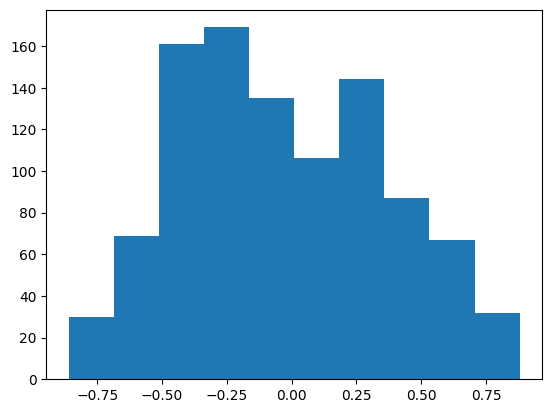

In [226]:
plt.hist(bd[5].cpu())

In [ ]:
C

64

(-1.0, 1.0)

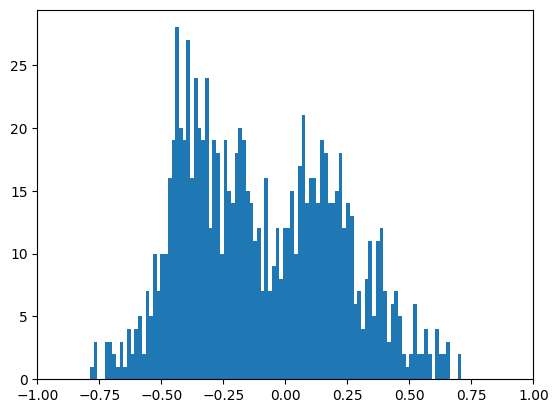

In [233]:
_ = plt.hist(bd[3].cpu(), bins=100)
plt.xlim([-1, 1])

In [23]:
r.shape

torch.Size([64, 100000, 1])

(-1.0, 1.0)

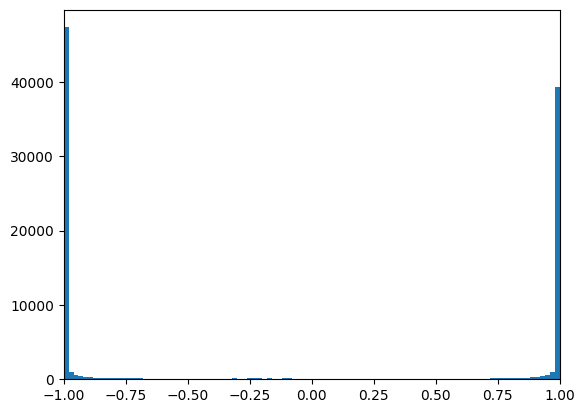

In [244]:
_ = plt.hist(r[9].flatten().cpu(), bins=100)
plt.xlim([-1, 1])

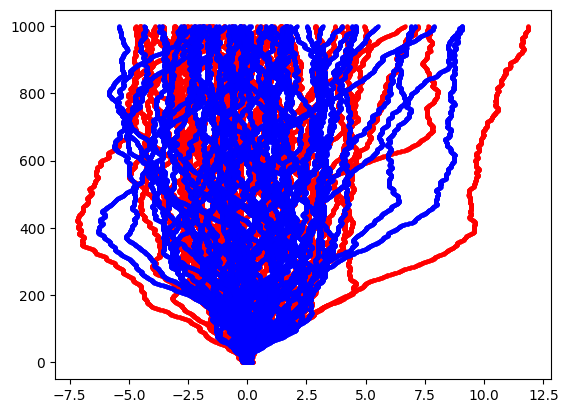

In [273]:
i = 0

ids = bd[i].argsort()[-50:].cpu()
plt.scatter(
    dataset['physics'][ids, :, 0],
    torch.arange(1000).reshape(1, -1).repeat(50, 1),
    c='red', s=5
)


ids = bd[i].argsort()[:50].cpu()
plt.scatter(
    dataset['physics'][ids, :, 0],
    torch.arange(1000).reshape(1, -1).repeat(50, 1),
    c='blue', s=5
)

In [ ]:
ids

tensor([100, 101, 102, 168, 205, 206, 449, 455, 512, 529, 539, 673, 689, 738,
        753, 768, 824, 692, 691, 509, 612, 403, 193, 508, 155, 663, 335, 453,
        717, 446, 128, 456, 767, 103, 737,  48,  57,  60,  68,  71,  73,  89,
         92, 125, 126, 144, 152, 153, 163, 165])

In [ ]:
[s for s in mlps.mlps[0][0].__dir__() if not '__' in s]

['T_destination',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_persistent_buffers_set',
 '_parameters',
 '_register_load_state_dict_pre_hook',
 '_register_state_dict_hook',
 '_replicate_for_data_parallel',
 '_save_to_state_dict',
 '_slow_forward',
 '_state_dict_hooks',
 '_state_dict_pre_hooks',
 '_version',
 '_wrapped_call_impl',
 'add_module',
 'apply',
 'bfloat16',
 'bias',
 'buffers',
 'call_super_init',
 'children',
 'compile',
 'cpu',
 'cuda',
 'double',
 'dump_patches',
 'eval',
 'extra_repr',
 'float',
 'forward',
 'get_buff